In [ ]:
# 05 Feature Engineering

## Objective

Feature Engineering involves creating new variables from existing data to better represent customer financial behavior.

These engineered features provide additional insights into repayment capacity, debt burden, and financial stability.

In [1]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)

In [2]:
df = pd.read_csv("cleaned_application_train.csv")

In [3]:
print(df.shape)

(307511, 105)


In [7]:
df["INCOME_CREDIT_RATIO"] = (
    df["AMT_INCOME_TOTAL"] /
    df["AMT_CREDIT"]
)

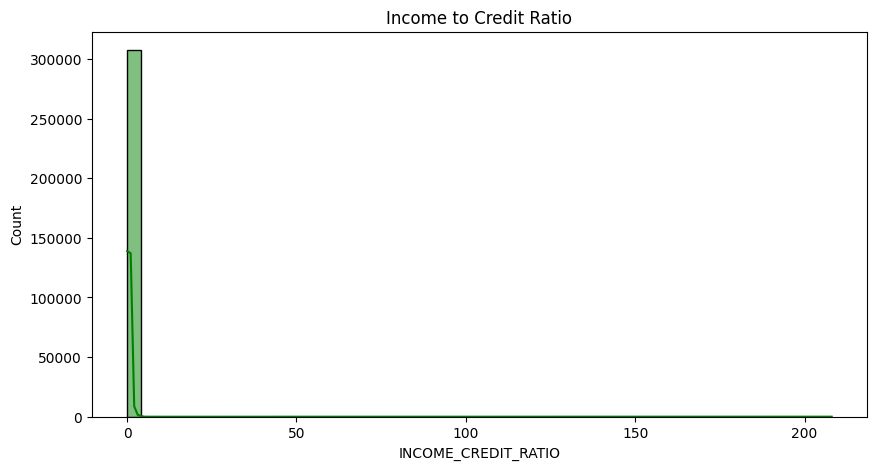

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))

sns.histplot(
    df["INCOME_CREDIT_RATIO"],
    bins=50,
    kde=True,
    color="green"
)

plt.title("Income to Credit Ratio")

plt.show()

In [19]:
### Business Insight

# Higher values indicate applicants whose annual income is relatively high compared to the requested loan amount. 
# Such applicants may have stronger repayment capacity.

In [20]:
df["CREDIT_INCOME_RATIO"] = (
    df["AMT_CREDIT"] /
    df["AMT_INCOME_TOTAL"]
)

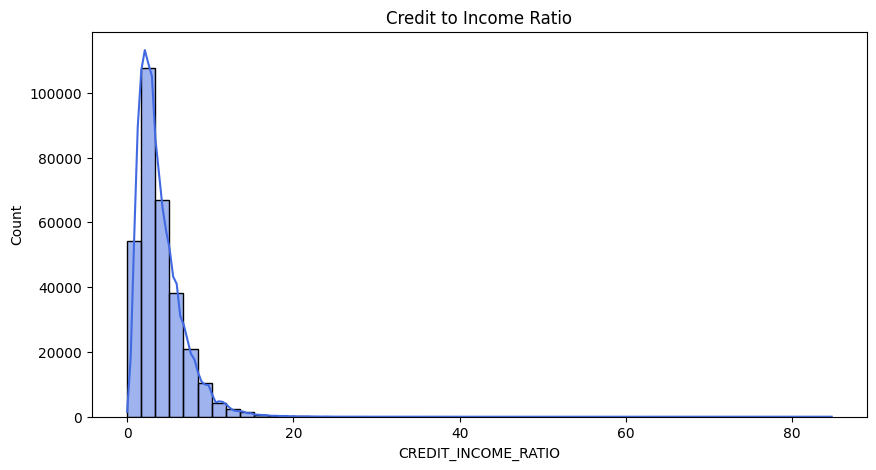

In [21]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["CREDIT_INCOME_RATIO"],
    bins=50,
    kde=True,
    color="royalblue"
)

plt.title("Credit to Income Ratio")

plt.show()

In [22]:
df["ANNUITY_INCOME_RATIO"] = (
    df["AMT_ANNUITY"] /
    df["AMT_INCOME_TOTAL"]
)

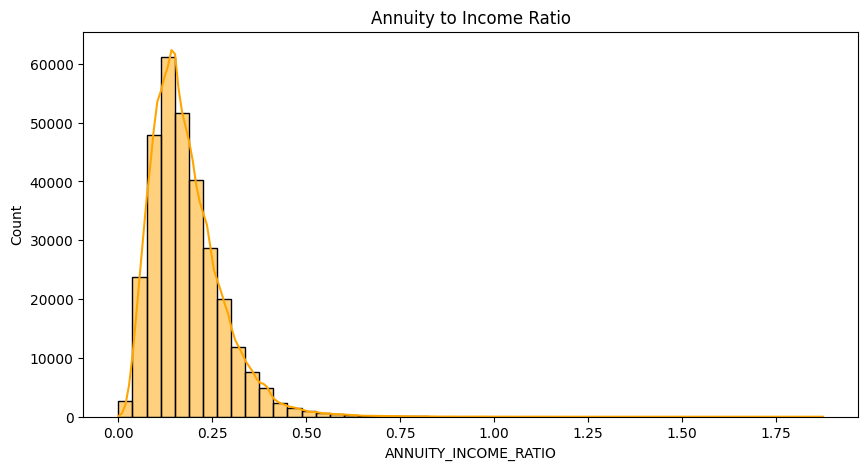

In [23]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["ANNUITY_INCOME_RATIO"],
    bins=50,
    kde=True,
    color="orange"
)

plt.title("Annuity to Income Ratio")

plt.show()

In [24]:
df["EMPLOYMENT_YEARS"] = (
    -df["DAYS_EMPLOYED"] / 365
)

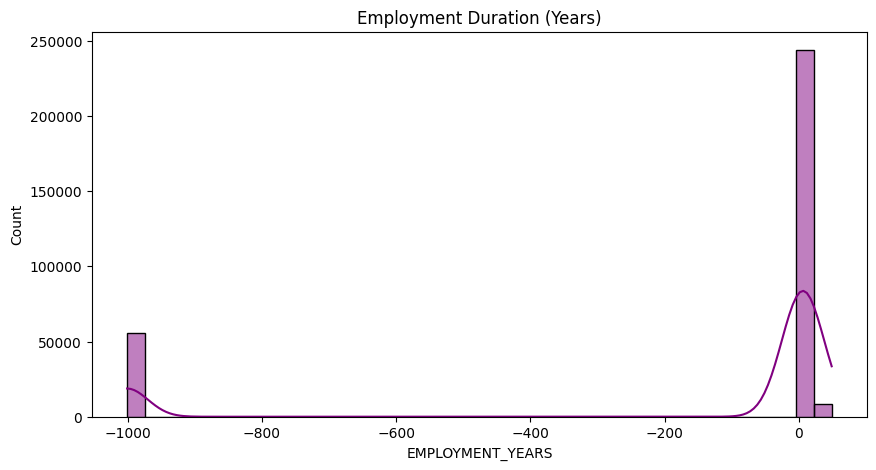

In [25]:
plt.figure(figsize=(10,5))

sns.histplot(
    df["EMPLOYMENT_YEARS"],
    bins=40,
    kde=True,
    color="purple"
)

plt.title("Employment Duration (Years)")

plt.show()

In [28]:
df["AGE"] = (-df["DAYS_BIRTH"] / 365).astype(int)

In [29]:
bins = [18, 25, 35, 45, 55, 65, 100]

labels = [
    "18-25",
    "26-35",
    "36-45",
    "46-55",
    "56-65",
    "65+"
]

df["AGE_GROUP"] = pd.cut(
    df["AGE"],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [30]:
print(df.columns.tolist())

['SK_ID_CURR', 'TARGET', 'NAME_CONTRACT_TYPE', 'CODE_GENDER', 'FLAG_OWN_CAR', 'FLAG_OWN_REALTY', 'CNT_CHILDREN', 'AMT_INCOME_TOTAL', 'AMT_CREDIT', 'AMT_ANNUITY', 'AMT_GOODS_PRICE', 'NAME_TYPE_SUITE', 'NAME_INCOME_TYPE', 'NAME_EDUCATION_TYPE', 'NAME_FAMILY_STATUS', 'NAME_HOUSING_TYPE', 'REGION_POPULATION_RELATIVE', 'DAYS_BIRTH', 'DAYS_EMPLOYED', 'DAYS_REGISTRATION', 'DAYS_ID_PUBLISH', 'FLAG_MOBIL', 'FLAG_EMP_PHONE', 'FLAG_WORK_PHONE', 'FLAG_CONT_MOBILE', 'FLAG_PHONE', 'FLAG_EMAIL', 'OCCUPATION_TYPE', 'CNT_FAM_MEMBERS', 'REGION_RATING_CLIENT', 'REGION_RATING_CLIENT_W_CITY', 'WEEKDAY_APPR_PROCESS_START', 'HOUR_APPR_PROCESS_START', 'REG_REGION_NOT_LIVE_REGION', 'REG_REGION_NOT_WORK_REGION', 'LIVE_REGION_NOT_WORK_REGION', 'REG_CITY_NOT_LIVE_CITY', 'REG_CITY_NOT_WORK_CITY', 'LIVE_CITY_NOT_WORK_CITY', 'ORGANIZATION_TYPE', 'EXT_SOURCE_1', 'EXT_SOURCE_2', 'EXT_SOURCE_3', 'APARTMENTS_AVG', 'BASEMENTAREA_AVG', 'YEARS_BEGINEXPLUATATION_AVG', 'ELEVATORS_AVG', 'ENTRANCES_AVG', 'FLOORSMAX_AVG', 'LAND

In [32]:
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

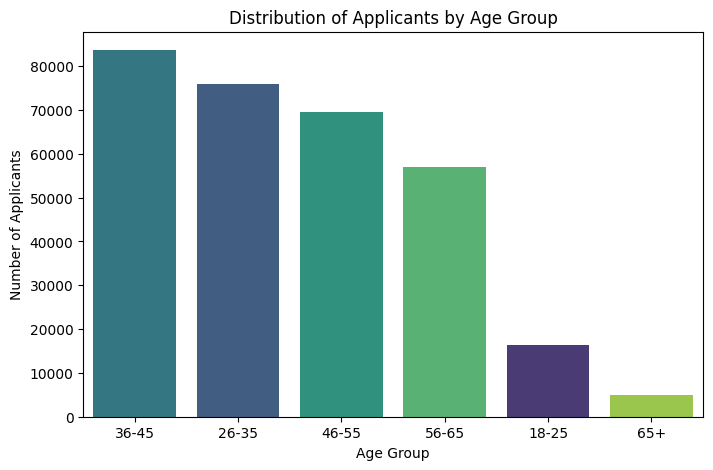

In [33]:
plt.figure(figsize=(8,5))

sns.countplot(
    data=df,
    x="AGE_GROUP",
    order=df["AGE_GROUP"].value_counts().index,
    hue="AGE_GROUP",
    palette="viridis",
    legend=False
)

plt.title("Distribution of Applicants by Age Group")
plt.xlabel("Age Group")
plt.ylabel("Number of Applicants")

plt.show()